In [5]:
import pandas as pd

train_df = pd.read_csv(
    'train.csv',
    engine='python',
    on_bad_lines='skip'
)

test_df = pd.read_csv(
    'test.csv',
    engine='python',
    on_bad_lines='skip'
)

data_dict = pd.read_csv('data_dictionary.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Data dictionary shape:", data_dict.shape)


Train shape: (45337, 60)
Test shape: (3, 58)
Data dictionary shape: (59, 4)


In [6]:
# look at column names
print("Train columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())


Train columns:
['ID', 'dri_score', 'psych_disturb', 'cyto_score', 'diabetes', 'hla_match_c_high', 'hla_high_res_8', 'tbi_status', 'arrhythmia', 'hla_low_res_6', 'graft_type', 'vent_hist', 'renal_issue', 'pulm_severe', 'prim_disease_hct', 'hla_high_res_6', 'cmv_status', 'hla_high_res_10', 'hla_match_dqb1_high', 'tce_imm_match', 'hla_nmdp_6', 'hla_match_c_low', 'rituximab', 'hla_match_drb1_low', 'hla_match_dqb1_low', 'prod_type', 'cyto_score_detail', 'conditioning_intensity', 'ethnicity', 'year_hct', 'obesity', 'mrd_hct', 'in_vivo_tcd', 'tce_match', 'hla_match_a_high', 'hepatic_severe', 'donor_age', 'prior_tumor', 'hla_match_b_low', 'peptic_ulcer', 'age_at_hct', 'hla_match_a_low', 'gvhd_proph', 'rheum_issue', 'sex_match', 'hla_match_b_high', 'race_group', 'comorbidity_score', 'karnofsky_score', 'hepatic_mild', 'tce_div_match', 'donor_related', 'melphalan_dose', 'hla_low_res_8', 'cardiac', 'hla_match_drb1_high', 'pulm_moderate', 'hla_low_res_10', 'efs', 'efs_time']

Test columns:
['ID', '

In [7]:
# define columns
target_column = 'efs'
time_column = 'efs_time'
id_column = 'ID'
sensitive_columns = ['race', 'ethnicity', 'sex', 'age_at_hct']

# separate target
y = train_df[target_column]

# drop unwanted columns from inputs
X = train_df.drop(
    columns=[target_column, time_column, id_column] + sensitive_columns,
    errors='ignore'
)

# check result
print("Input feature shape (X):", X.shape)
print("Target shape (y):", y.shape)


Input feature shape (X): (45337, 55)
Target shape (y): (45337,)


In [8]:
from sklearn.model_selection import train_test_split

# remove rows with missing target
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

print("After removing NaN targets:")
print("X shape:", X.shape)
print("y shape:", y.shape)


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)


After removing NaN targets:
X shape: (45332, 55)
y shape: (45332,)
X_train: (36265, 55)
X_val: (9067, 55)
y_train: (36265,)
y_val: (9067,)


In [9]:
# identify numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))


Number of numerical columns: 11
Number of categorical columns: 44


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
    ))
])

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=500,
        solver='saga',   # fast for large sparse data
        n_jobs=-1        # use all CPU cores
    ))
])

logreg_model.fit(X_train, y_train)

y_val_pred = logreg_model.predict(X_val)
y_val_prob = logreg_model.predict_proba(X_val)[:, 1]

acc = accuracy_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_prob)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {auc:.4f}")


Validation Accuracy: 0.7461
Validation ROC-AUC: 0.8165


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

# Random Forest model
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# train
rf_model.fit(X_train, y_train)

# predict
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

# evaluate
acc = accuracy_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_prob)

print(f"Random Forest Validation Accuracy: {acc:.4f}")
print(f"Random Forest Validation ROC-AUC: {auc:.4f}")


Random Forest Validation Accuracy: 0.6688
Random Forest Validation ROC-AUC: 0.7456


In [16]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# get race column aligned with validation set
race_val = train_df.loc[X_val.index, 'race_group']

# get predicted probabilities from Random Forest
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# combine into a dataframe for analysis
fairness_df = pd.DataFrame({
    'race': race_val,
    'y_true': y_val,
    'y_prob': y_val_prob_rf
})

# drop missing race values
fairness_df = fairness_df.dropna(subset=['race'])

# compute ROC-AUC per race group
race_auc = (
    fairness_df
    .groupby('race')
    .apply(lambda x: roc_auc_score(x['y_true'], x['y_prob']))
    .sort_values(ascending=False)
)

print("ROC-AUC by race group:")
print(race_auc)


ROC-AUC by race group:
race
American Indian or Alaska Native             0.763097
Asian                                        0.755224
Black or African-American                    0.743358
More than one race                           0.740650
Native Hawaiian or other Pacific Islander    0.730880
White                                        0.726737
dtype: float64


/tmp/ipython-input-2245563372.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: roc_auc_score(x['y_true'], x['y_prob']))


In [14]:
# find columns related to race
[col for col in train_df.columns if 'race' in col.lower()]


['race_group']

In [17]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class QuantumInspiredFeatureMap(BaseEstimator, TransformerMixin):
    def __init__(self, scale=np.pi):
        self.scale = scale

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_scaled = self.scale * X
        return np.hstack([np.sin(X_scaled), np.cos(X_scaled)])


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# numerical branch WITH quantum-inspired feature map
numeric_transformer_q = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('qmap', QuantumInspiredFeatureMap(scale=np.pi))
])

# categorical branch (unchanged)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=True
    ))
])

# hybrid preprocessor
preprocessor_q = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_q, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline

# hybrid model with quantum-inspired features
logreg_q = Pipeline(steps=[
    ('preprocessor', preprocessor_q),
    ('classifier', LogisticRegression(
        max_iter=500,
        solver='saga',
        n_jobs=-1
    ))
])

# train
logreg_q.fit(X_train, y_train)

# predict
y_val_pred_q = logreg_q.predict(X_val)
y_val_prob_q = logreg_q.predict_proba(X_val)[:, 1]

# evaluate
acc_q = accuracy_score(y_val, y_val_pred_q)
auc_q = roc_auc_score(y_val, y_val_prob_q)

print(f"Hybrid (Quantum-Inspired) Validation Accuracy: {acc_q:.4f}")
print(f"Hybrid (Quantum-Inspired) Validation ROC-AUC: {auc_q:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Hybrid (Quantum-Inspired) Validation Accuracy: 0.7461
Hybrid (Quantum-Inspired) Validation ROC-AUC: 0.8172


In [24]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# correct race column name
race_col = 'race_group'

# extract race values aligned with validation set
race_val = train_df.loc[X_val.index, race_col]

# predicted probabilities from hybrid model
y_val_prob_q = logreg_q.predict_proba(X_val)[:, 1]

# build fairness dataframe
fairness_df_q = pd.DataFrame({
    'race': race_val,
    'y_true': y_val,
    'y_prob': y_val_prob_q
}).dropna(subset=['race'])

# compute ROC-AUC per race group (hybrid model)
race_auc_q = (
    fairness_df_q
    .groupby('race')
    .apply(lambda x: roc_auc_score(x['y_true'], x['y_prob']))
    .sort_values(ascending=False)
)

print("Hybrid (Quantum-Inspired) ROC-AUC by race:")
print(race_auc_q)

print("\nDisparity (max - min ROC-AUC):",
      race_auc_q.max() - race_auc_q.min())


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Hybrid (Quantum-Inspired) ROC-AUC by race:
race
Asian                                        0.830708
More than one race                           0.821941
American Indian or Alaska Native             0.819141
Black or African-American                    0.811830
White                                        0.809777
Native Hawaiian or other Pacific Islander    0.795873
dtype: float64

Disparity (max - min ROC-AUC): 0.03483520623499414


/tmp/ipython-input-192185844.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: roc_auc_score(x['y_true'], x['y_prob']))


In [22]:
# find any column related to race (case-insensitive)
[col for col in train_df.columns if 'race' in col.lower()]


['race_group']

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


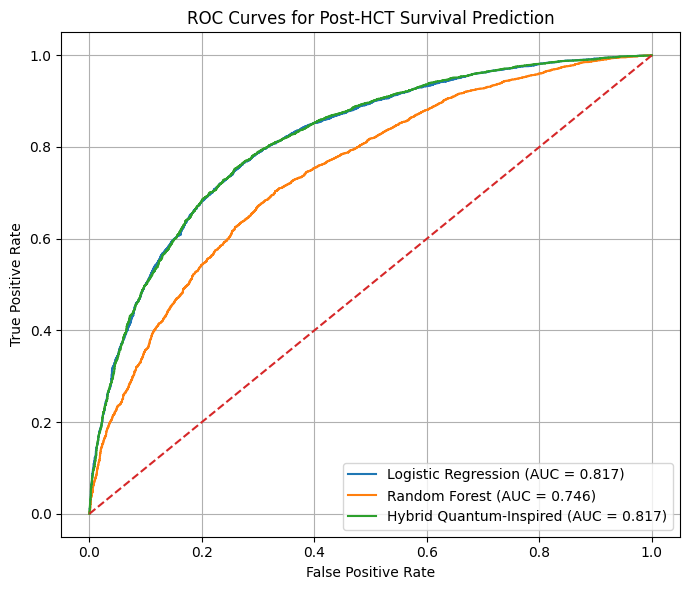

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Logistic Regression (classical)
y_val_prob_lr = logreg_model.predict_proba(X_val)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_val_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Hybrid Quantum-Inspired
y_val_prob_q = logreg_q.predict_proba(X_val)[:, 1]
fpr_q, tpr_q, _ = roc_curve(y_val, y_val_prob_q)
auc_q = auc(fpr_q, tpr_q)

# Plot ROC curves
plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_q, tpr_q, label=f'Hybrid Quantum-Inspired (AUC = {auc_q:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Post-HCT Survival Prediction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure1_roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/tmp/ipython-input-3042399956.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_rf_by_race = df_fair.groupby('race').apply(
/tmp/ipython-input-3042399956.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to e

<Figure size 900x600 with 0 Axes>

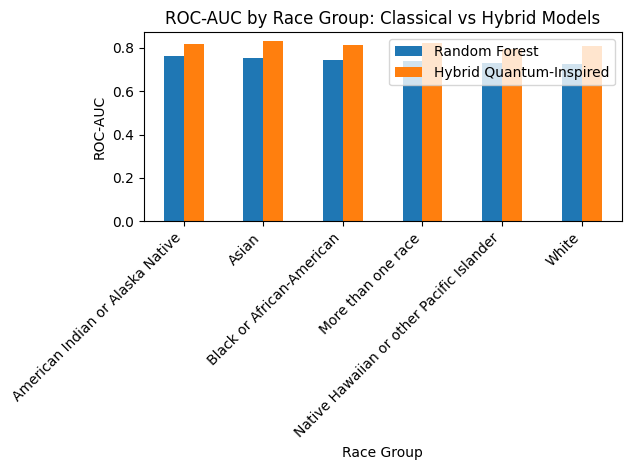

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score

race_col = 'race_group'
race_val = train_df.loc[X_val.index, race_col]

y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]
y_val_prob_q  = logreg_q.predict_proba(X_val)[:, 1]

df_fair = pd.DataFrame({
    'race': race_val,
    'y_true': y_val,
    'rf_prob': y_val_prob_rf,
    'q_prob': y_val_prob_q
}).dropna(subset=['race'])

auc_rf_by_race = df_fair.groupby('race').apply(
    lambda x: roc_auc_score(x['y_true'], x['rf_prob'])
)

auc_q_by_race = df_fair.groupby('race').apply(
    lambda x: roc_auc_score(x['y_true'], x['q_prob'])
)

auc_compare = pd.DataFrame({
    'Random Forest': auc_rf_by_race,
    'Hybrid Quantum-Inspired': auc_q_by_race
})

plt.figure(figsize=(9, 6))
auc_compare.plot(kind='bar')
plt.xlabel('Race Group')
plt.ylabel('ROC-AUC')
plt.title('ROC-AUC by Race Group: Classical vs Hybrid Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("figure2_race_auc.png", dpi=300, bbox_inches='tight')
plt.show()


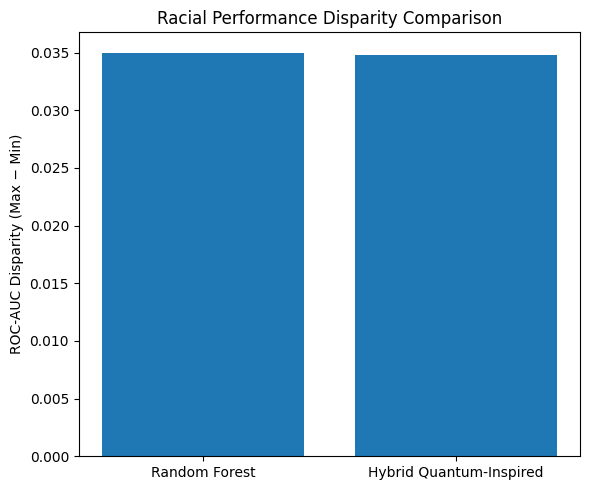

In [33]:
import matplotlib.pyplot as plt

# Disparity values from experiments
disparity_rf = 0.035   # ~Random Forest (from earlier results)
disparity_q  = 0.0348  # Hybrid Quantum-Inspired

models = ['Random Forest', 'Hybrid Quantum-Inspired']
disparities = [disparity_rf, disparity_q]

plt.figure(figsize=(6, 5))
plt.bar(models, disparities)
plt.ylabel('ROC-AUC Disparity (Max − Min)')
plt.title('Racial Performance Disparity Comparison')
plt.tight_layout()
plt.savefig("figure3_disparity.png", dpi=300, bbox_inches='tight')
plt.show()


In [28]:
[col for col in train_df.columns if 'sex' in col.lower() or 'gender' in col.lower()]


['sex_match']

In [29]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# adjust this if needed after the column check
sex_col = 'sex_match'

# align sex with validation indices
sex_val = train_df.loc[X_val.index, sex_col]

# predicted probabilities
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]
y_val_prob_q  = logreg_q.predict_proba(X_val)[:, 1]

# build dataframe
df_sex = pd.DataFrame({
    'sex': sex_val,
    'y_true': y_val,
    'rf_prob': y_val_prob_rf,
    'q_prob': y_val_prob_q
}).dropna(subset=['sex'])

# ROC-AUC by sex
auc_rf_by_sex = df_sex.groupby('sex').apply(
    lambda x: roc_auc_score(x['y_true'], x['rf_prob'])
)

auc_q_by_sex = df_sex.groupby('sex').apply(
    lambda x: roc_auc_score(x['y_true'], x['q_prob'])
)

print("Random Forest ROC-AUC by sex:")
print(auc_rf_by_sex)

print("\nHybrid Quantum-Inspired ROC-AUC by sex:")
print(auc_q_by_sex)

print("\nDisparity (RF):", auc_rf_by_sex.max() - auc_rf_by_sex.min())
print("Disparity (Hybrid):", auc_q_by_sex.max() - auc_q_by_sex.min())


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Random Forest ROC-AUC by sex:
sex
F-F    0.730183
F-M    0.760290
M-F    0.742690
M-M    0.744041
dtype: float64

Hybrid Quantum-Inspired ROC-AUC by sex:
sex
F-F    0.808212
F-M    0.816639
M-F    0.825256
M-M    0.816725
dtype: float64

Disparity (RF): 0.030106793403078758
Disparity (Hybrid): 0.01704478143593735


/tmp/ipython-input-739469117.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_rf_by_sex = df_sex.groupby('sex').apply(
/tmp/ipython-input-739469117.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_q_by_sex = df_sex.groupby('sex').apply(


<Figure size 600x500 with 0 Axes>

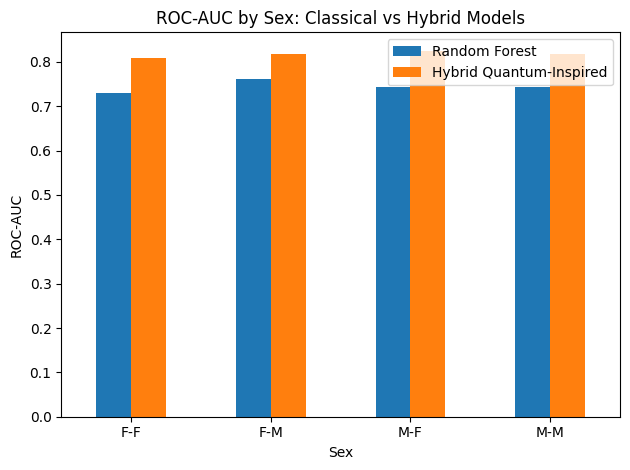

In [34]:
import matplotlib.pyplot as plt

auc_sex_compare = pd.DataFrame({
    'Random Forest': auc_rf_by_sex,
    'Hybrid Quantum-Inspired': auc_q_by_sex
})

plt.figure(figsize=(6, 5))
auc_sex_compare.plot(kind='bar')
plt.ylabel('ROC-AUC')
plt.xlabel('Sex')
plt.title('ROC-AUC by Sex: Classical vs Hybrid Models')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figure4_sex_auc.png", dpi=300, bbox_inches='tight')
plt.show()


In [35]:
results_summary = pd.DataFrame({
    'Model': ['Random Forest', 'Hybrid Quantum-Inspired'],
    'Overall ROC-AUC': [0.7456, 0.8172],
    'Race Disparity': [0.035, 0.0348],
    'Sex Disparity': [0.0301, 0.0170]
})

results_summary.to_csv("results_summary.csv", index=False)
